In [1]:
#Import Libs
from matplotlib import pyplot as plot
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import random
import math
import cv2

In [2]:
#Function to Load a Image from Github
def display_image_from_url(image_url):
    with urllib.request.urlopen(image_url) as url:
        s = url.read()
    img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [3]:
#Import Image
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/Fish01.jpg'
img = display_image_from_url(image_url)

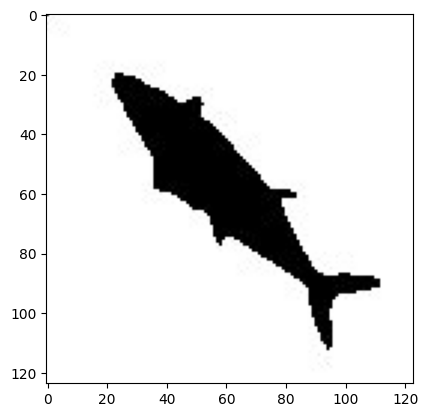

In [4]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

In [5]:
#Thresholding and Negative Conversion
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
ret_otsu, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
img = 255 - img

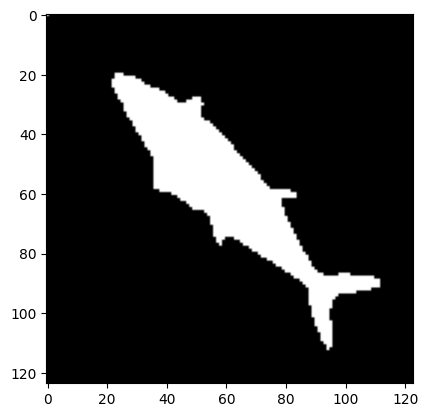

In [6]:
#Show the Result
plot.imshow(img,cmap='gray')
plot.show()

In [7]:
#Collect the Central Moments
M = cv2.moments(img)
print(M)

{'m00': 501075.0, 'm10': 30129270.0, 'm01': 29496360.0, 'm20': 2019824910.0, 'm11': 1964009745.0, 'm02': 1952097420.0, 'm30': 147847956540.0, 'm21': 143077788075.0, 'm12': 141032569755.0, 'm03': 141557085120.0, 'mu20': 208174137.69465664, 'mu11': 190415383.96183223, 'mu02': 215760038.8702291, 'mu30': 1362660587.588352, 'mu21': 1279383218.6271973, 'mu12': 1236348304.645752, 'mu03': 1242681456.572903, 'nu20': 0.0008291274700158284, 'nu11': 0.0007583969233869866, 'nu02': 0.0008593410168048056, 'nu30': 7.66709522273525e-06, 'nu21': 7.198529885526778e-06, 'nu12': 6.956391244104767e-06, 'nu03': 6.992025120455042e-06}


In [8]:
#Discovery the Object Centroid
cx = int(M['m10']/M['m00'])
cy = int(M['m01']/M['m00'])
print(cx,cy)

60 58


In [9]:
#Find the Object Orientation ( Angleº )
lamb = np.sqrt( (M['mu20']-M['mu02'])**2 + 4*M['mu11']**2 )
tan_theta = (M['mu02']-M['mu20'] - 2*M['mu11'] + lamb) / (M['mu02']-M['mu20'] + 2*M['mu11'] - lamb)
theta = math.pi-math.atan(tan_theta)
ang=theta/math.pi*180.0
if(ang>180): ang=ang-180

Object Angle:  134.42942812677452


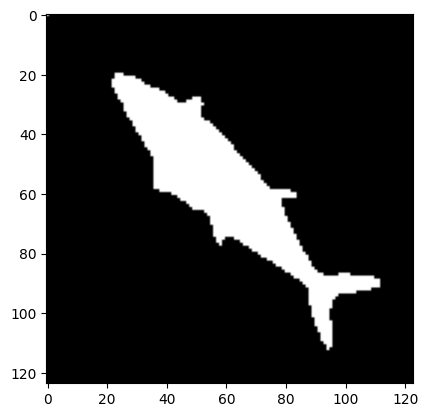

In [10]:
#Show the Results
plot.imshow(img, cmap = 'gray')
print('Object Angle: ',ang)

In [11]:
#Example 02
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/Fish02.jpg'
img = display_image_from_url(image_url)

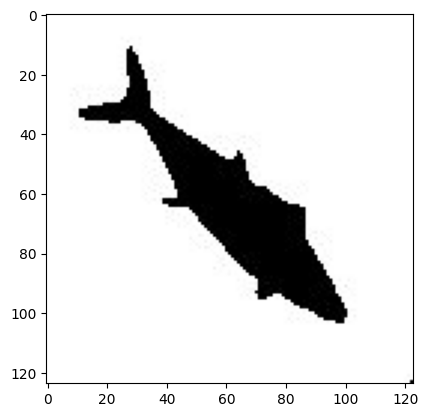

In [12]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

In [13]:
#Apply All Process
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
ret_otsu, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
img = 255 - img
M = cv2.moments(img)
cx = int(M['m10']/M['m00'])
cy = int(M['m01']/M['m00'])
lamb = np.sqrt( (M['mu20']-M['mu02'])**2 + 4*M['mu11']**2 )
tan_theta = (M['mu02']-M['mu20'] - 2*M['mu11'] + lamb) / (M['mu02']-M['mu20'] + 2*M['mu11'] - lamb)
theta = math.pi-math.atan(tan_theta)
ang=theta/math.pi*180.0
if(ang>180): ang=ang-180

Object Angle:  134.42942812677452


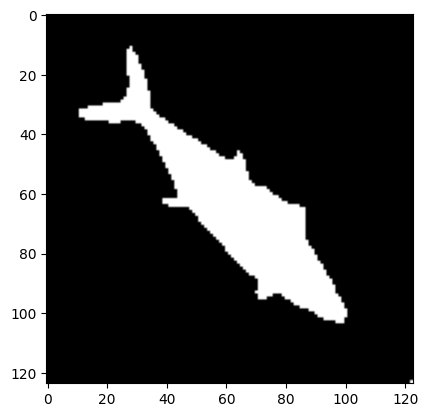

In [14]:
#Show the Results
plot.imshow(img, cmap = 'gray')
print('Object Angle: ',ang)

In [15]:
#Example 03
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/Fish03.jpg'
img = display_image_from_url(image_url)

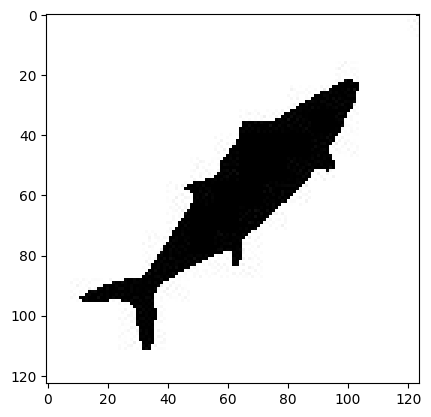

In [16]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

In [17]:
#Apply All Process
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
ret_otsu, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
img = 255 - img
M = cv2.moments(img)
cx = int(M['m10']/M['m00'])
cy = int(M['m01']/M['m00'])
lamb = np.sqrt( (M['mu20']-M['mu02'])**2 + 4*M['mu11']**2 )
tan_theta = (M['mu02']-M['mu20'] - 2*M['mu11'] + lamb) / (M['mu02']-M['mu20'] + 2*M['mu11'] - lamb)
theta = math.pi-math.atan(tan_theta)
ang=theta/math.pi*180.0
if(ang>180): ang=ang-180

Object Angle:  44.429428126774155


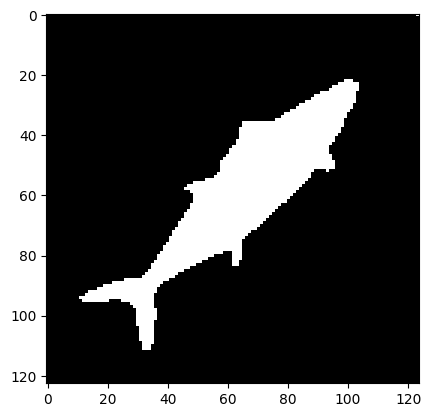

In [18]:
#Show the Results
plot.imshow(img, cmap = 'gray')
print('Object Angle: ',ang)

## **Hu Moments**

Hu Moments are a set of seven **invariant moments** derived from the central moments of an image. They are particularly useful in image processing and computer vision for **shape analysis and object recognition** because they possess properties of **translation, rotation, and scale invariance**.

This means that if an object is translated (moved), rotated, or scaled (resized) in an image, its Hu Moments will remain the same or very similar. This makes them robust features for comparing shapes, regardless of their position, orientation, or size in the image.

### How they are used:

1.  **Shape Descriptors**: They quantify different aspects of an object's shape, providing a compact numerical representation.
2.  **Image Retrieval**: You can use Hu Moments to search for similar shapes in a database of images.
3.  **Object Classification**: In machine learning, Hu Moments can serve as features to train a classifier to recognize specific objects.

### Log Transformation:

The code uses a logarithmic transformation on the Hu Moments (`-np.sign(momHu)*np.log10(np.abs(momHu))`). This is a common practice because:

*   **Large Range of Values**: The raw Hu Moments can have a very wide range of values, which might be difficult to work with directly in some algorithms.
*   **Scale Normalization**: The logarithmic transformation helps to normalize the scale of these values, making them more comparable and often improving the performance of subsequent algorithms that use these moments as features.
*   **Sign Preservation**: The `np.sign(momHu)` part ensures that the original sign of the moment is preserved after the `log10` operation, as logarithms are typically applied to positive numbers. This is important because the sign can carry meaningful information about the shape's symmetry.

In [19]:
#Numbers Supression ( Scientific Notation )
np.set_printoptions(suppress=True)

In [20]:
# Calculate the Hu Moments and Applying the Log Transformation
momHu = cv2.HuMoments(M)
momHuT = -np.sign(momHu)*np.log10(np.abs(momHu))

In [21]:
#Show the Moments Hu
print(momHu)

[[ 0.00168847]
 [ 0.0000023 ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [-0.        ]]
